Run and Upload 'best_model.keras' and 'banana_test.webp' Files here:

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
from google.colab import files
uploaded = files.upload()

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/banana_project'):
    for filename in filenames:
       print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Saving banana_test.webp to banana_test.webp
Saving best_model.keras to best_model.keras


Check if files uploaded successfully:

In [4]:
import os
print(os.listdir('/content'))

['.config', 'banana_test.webp', 'best_model.keras', 'sample_data']


Install Ultralytics:

In [6]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


Keras Components from TensorFlow:

In [8]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Import necessary Keras components from tensorflow
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from ultralytics import YOLO

IMG_SIZE = 640
NUM_CLASSES = 4 # Added as it's used in build_model
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

CLASSIFIER_MODEL_PATH = '/content/best_model.keras'
YOLO_MODEL_PATH = '/content/runs/detect/train/weights/best.pt'

Run to Build MobileNetV2 model:

In [11]:
def build_model():

    # Load pre-trained MobileNetV2 (without top classification layer)
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model layers
    base_model.trainable = False

    # Build complete model - SAME AS YOUR ORIGINAL
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # Compile model - SAME AS YOUR ORIGINAL
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Install Roboflow and Update Secret API Key:

In [10]:
!pip install roboflow -q

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("marias-workspace-nru3u").project("banana-finder-faan5")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Finder-1 in yolov11:: 100%|██████████| 387/387 [00:00<00:00, 4070.12it/s]


Check if needed file paths are still stored in Colab:

In [13]:
import os
print(os.path.exists('/content/best_model.keras'))
print(os.path.exists('/content/runs/detect/train/weights/best.pt'))
print(os.path.exists('/content/banana_test.webp'))

True
False
True


Train YOLOv11 Model:

In [14]:
!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=25 imgsz=640

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Banana-Finder-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

Install Keras for Classification model:

In [15]:
!pip uninstall keras -y
!pip install keras==3.10.0 -q

Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.10.0 which is incompatible.


Run to 'merge' both models:

In [16]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

# Builds the model architecture first
model = build_model()

# Loads only the weights into the freshly built model
model.load_weights(CLASSIFIER_MODEL_PATH)

yolo_model = YOLO(YOLO_MODEL_PATH)

def classify_crop(crop_rgb):
    crop_resized = cv2.resize(crop_rgb, (640, 640))
    crop_array = crop_resized.astype(np.float32) / 255.0
    crop_array = np.expand_dims(crop_array, axis=0)

    prediction = model.predict(crop_array, verbose=0)
    class_idx = np.argmax(prediction)
    label = CLASS_NAMES[class_idx]
    confidence = float(prediction[0][class_idx])

    return label, confidence

`input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 


Run for updated TensorFlow and Keras version sync:

In [17]:
import tensorflow as tf
import keras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.19.0
Keras Version: 3.13.2


Run for detection and classification on the test image:

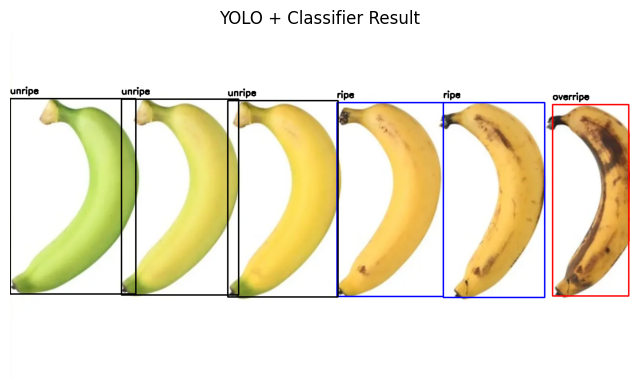

In [20]:
import matplotlib.pyplot as plt
import cv2
import numpy as np # Ensure numpy is imported for classify_crop

random_img_path = '/content/banana_test.webp'

img_bgr = cv2.imread(random_img_path)

# Add a check to ensure the image was loaded successfully
if img_bgr is None:
    print(f"Error: Could not load image from {random_img_path}")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # The global classify_crop function (now using keras_classifier_model) will be used

    results = yolo_model.predict(random_img_path, conf=0.60, verbose=False)

    found = False

    # Define a color map for each class
    color_map = {
        'overripe': (255, 0, 0),    # Red
        'ripe': (0, 0, 255),        # Blue
        'rotten': (0, 255, 0),      # Green
        'unripe': (0, 0, 0)         # Black
    }

    for result in results:
        boxes = result.boxes

        if boxes is None or len(boxes) == 0:
            continue

        for box in boxes:
            found = True

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_rgb.shape[1], x2)
            y2 = min(img_rgb.shape[0], y2)

            crop = img_rgb[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            # Call the globally defined classify_crop function
            label, confidence = classify_crop(crop)
            det_conf = float(box.conf[0].cpu().numpy())

            text = f"{label}"

            # Get the color based on the predicted label, default to white if not found
            box_color = color_map.get(label, (255, 255, 255)) # Default to White

            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), box_color, 2)
            cv2.putText(
                img_rgb,
                text,
                (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,0),
                2
            )

    if not found:
        print("No bananas detected.")

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title("YOLO + Classifier Result")
    plt.axis('off')
    plt.show()

Confusion Matrix:

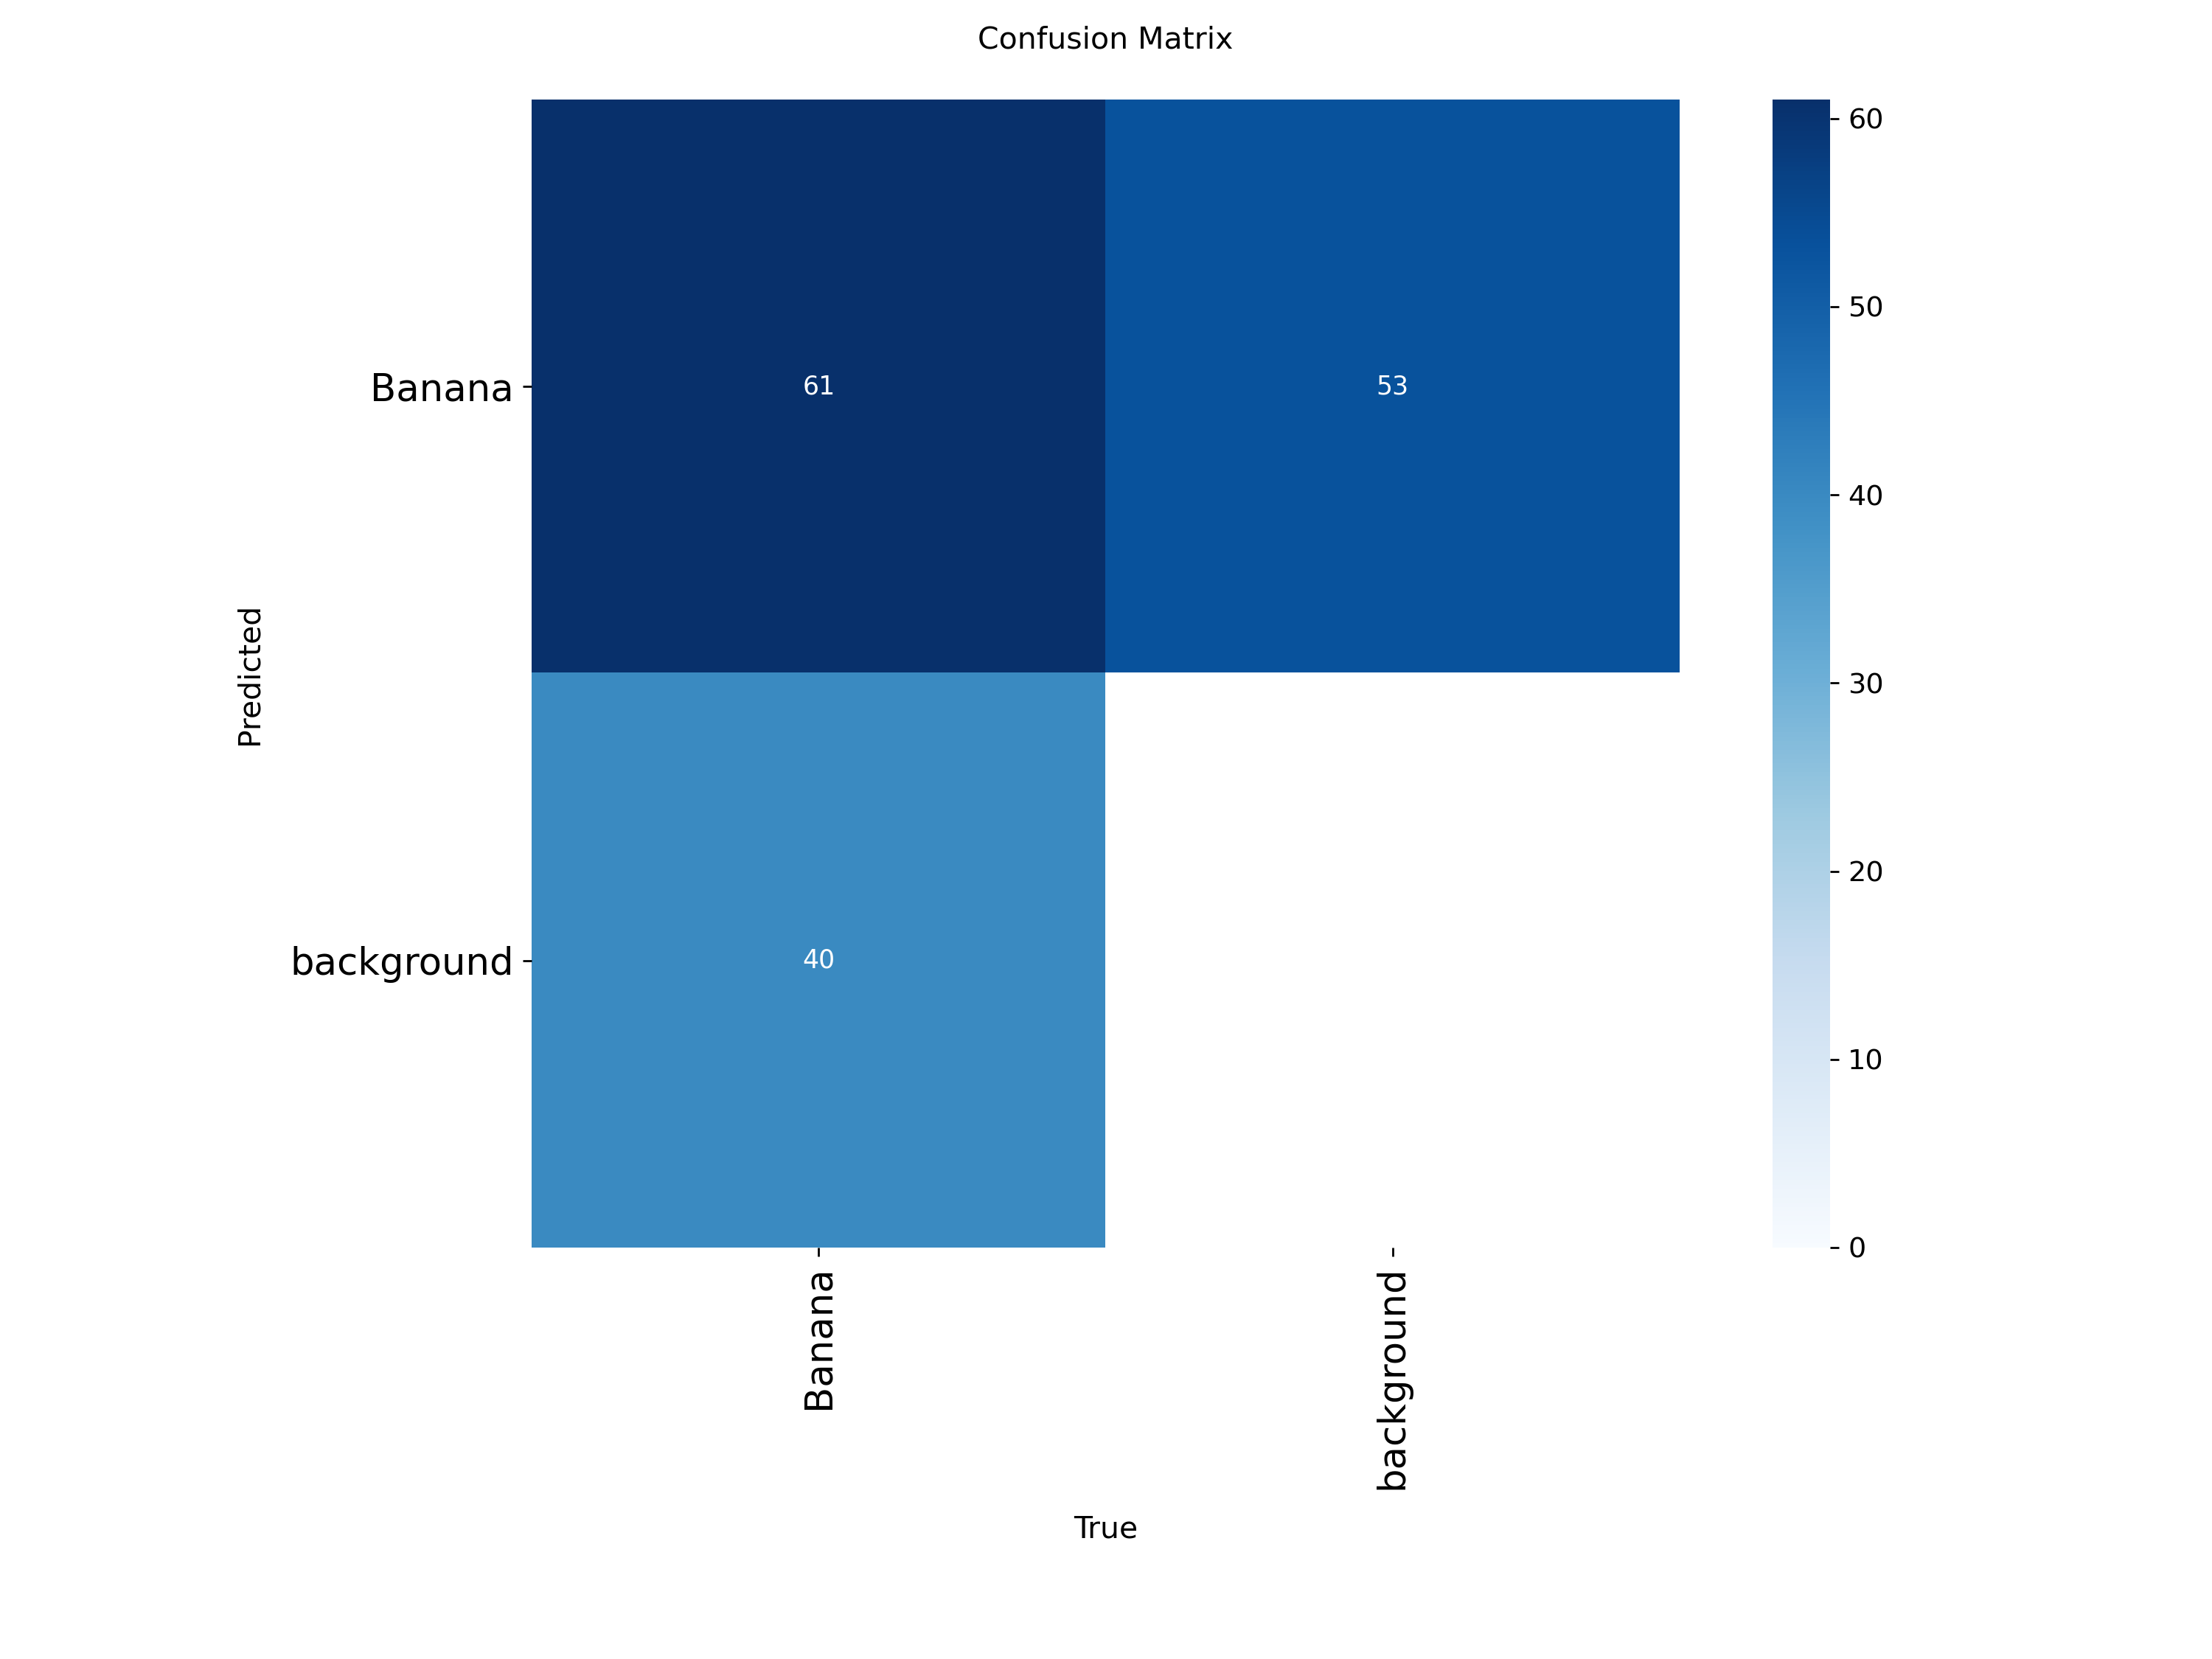

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content//runs/detect/train/confusion_matrix.png', width=600)

Model Validation:

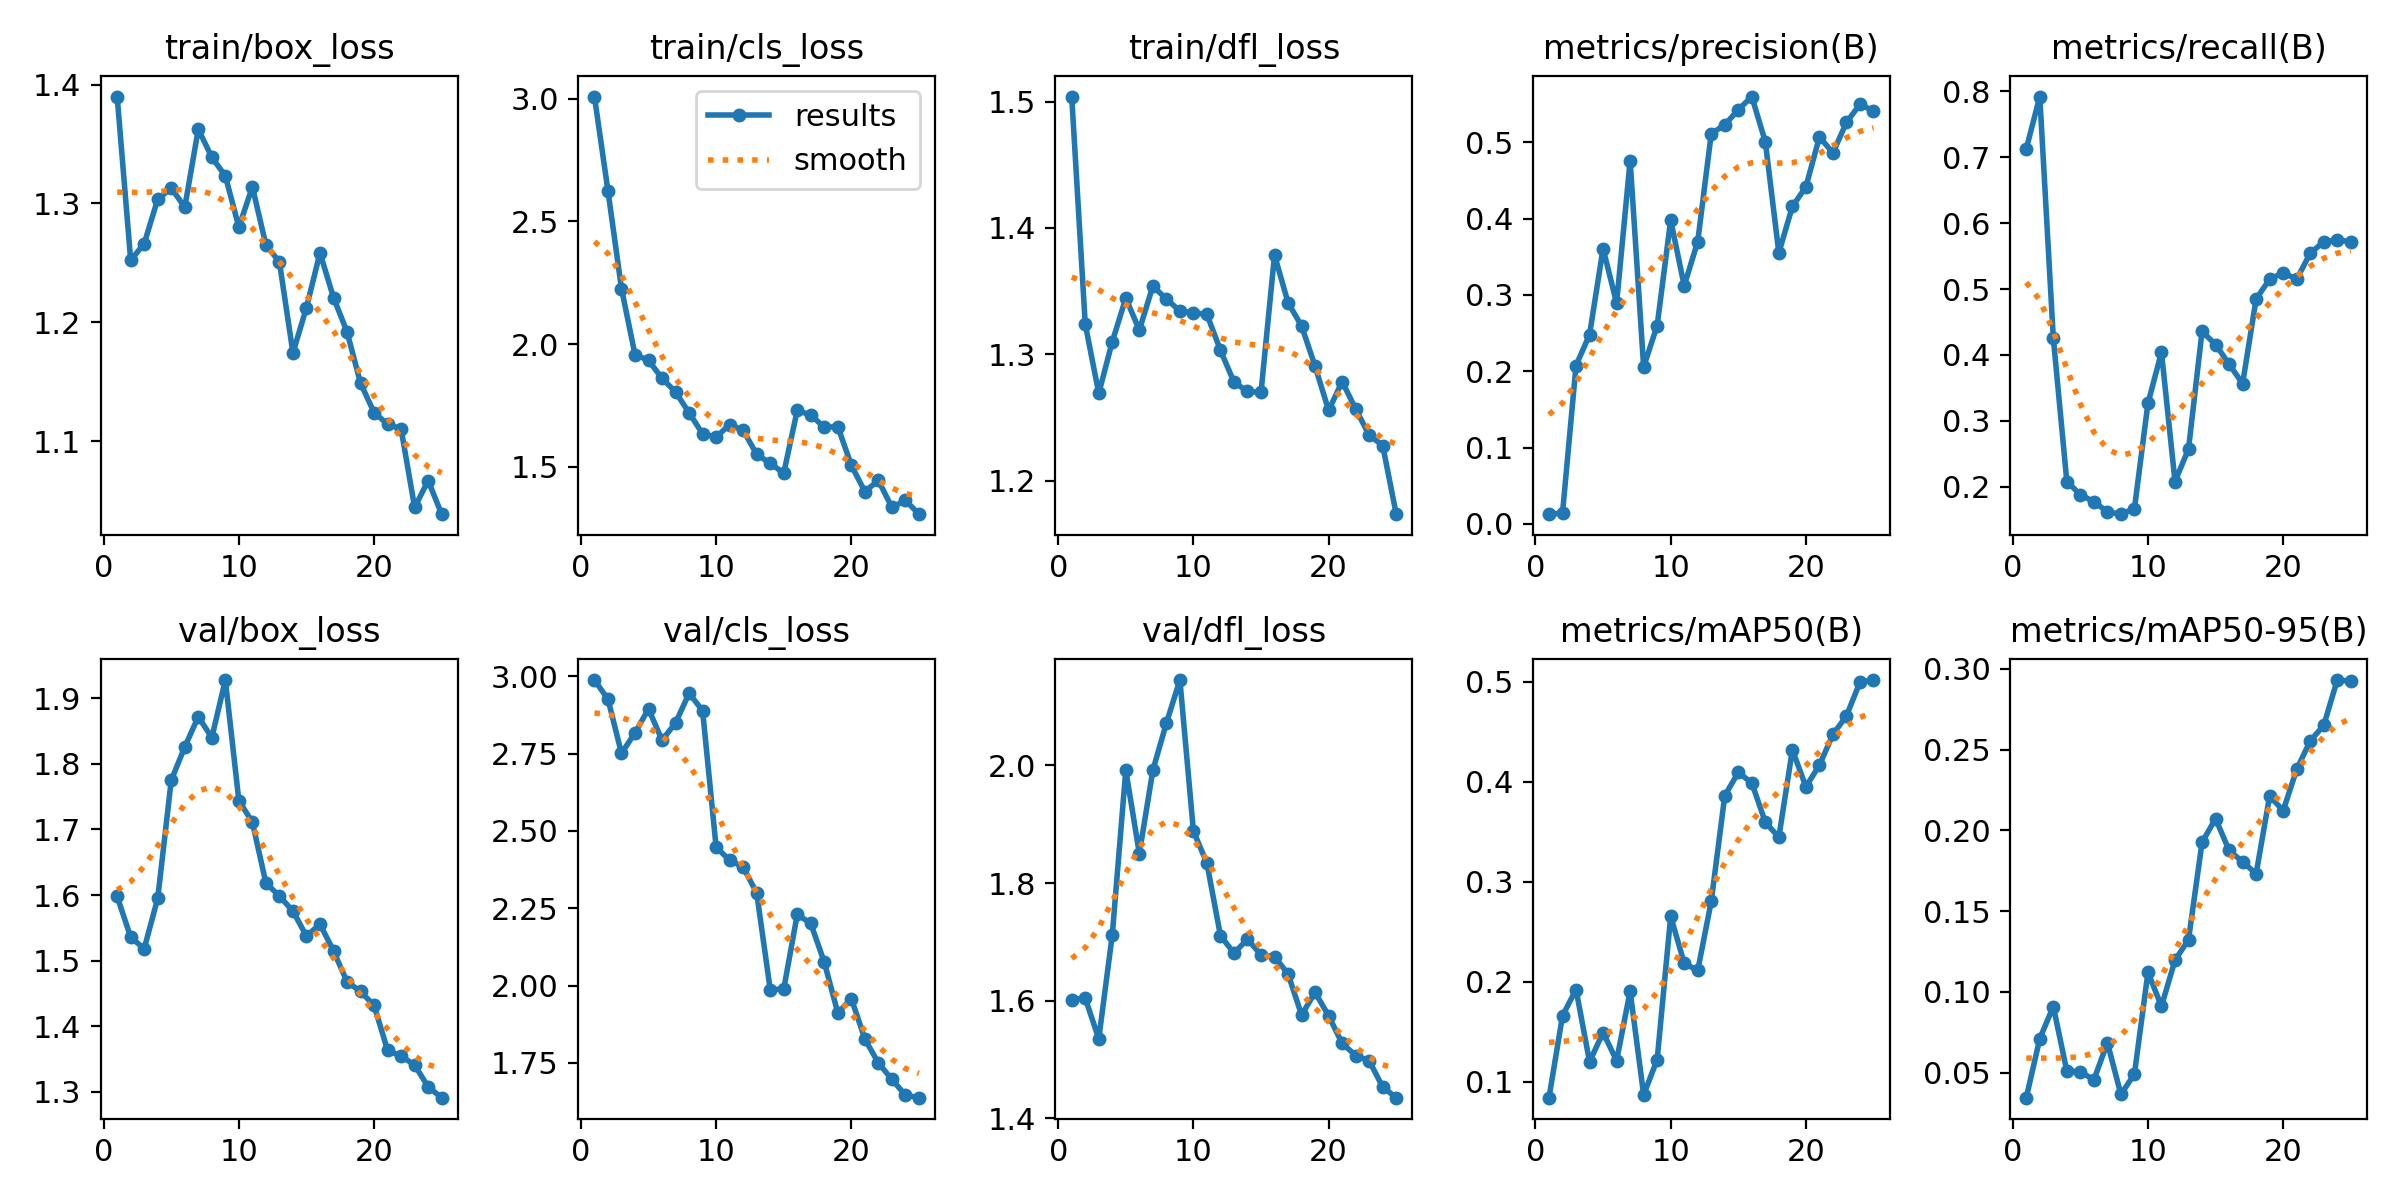

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/results.png', width=600)

In [ ]:
from ultralytics import YOLO

# Load your trained YOLO model for validation (using a distinct variable name)
yolo_validation_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run validation
metrics = yolo_validation_model.val()

# Access specific metrics
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"F1-Score: {metrics.box.f1}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1492.1±214.1 MB/s, size: 46.9 KB)
val: Scanning /content/Banana-Finder-1/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 4.7Mit/s 0.0s
val: /content/Banana-Finder-1/valid/images/images-41-_jpg.rf.02b4fa24d69454874b0e92d0e791e35b.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         19        101      0.551      0.574      0.501      0.294
Speed: 14.0ms preprocess, 8.1ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP50: 0.5014994894628864
mAP50-95: 0.2936199367957938
Precision: 0.5506793443236009
Recall: 0.5742574257425742
F1-Score: [    0.56222]
